In [1]:
import notebook_setup
import matplotlib.pyplot as plt
import numpy as np
import json
from matplotlib.ticker import ScalarFormatter

from src.plot_style import set_plot_style
from plot_utils import create_figure
from plot_config import get_colors, get_marker

set_plot_style()

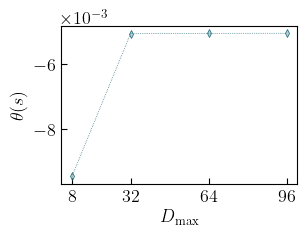

In [ ]:
fig, ax = create_figure(6.0, 4.0, margin_cm=2.0)

with open('figures_data/convergence_data.json', 'r') as f:
    data = json.load(f)

num_sites_range = np.array([4, 6, 8, 10, 20, 40, 60])
max_bond_dim_range = np.array([8, 32, 64, 96])

s = 0.01; V = 2.000
colors = get_colors(V)
colors_soft = get_colors(V, alpha=0.3)
marker = get_marker(V)

for n, L in enumerate(num_sites_range):
    values = data[f"s_{s:.3f}"][f"V_{V:.3f}"][f"L_{L}"]["theta"]
    ax.plot(max_bond_dim_range, values, marker=marker, markersize=4.0, markeredgewidth=0.5, ls=':', lw=0.5, c=colors[n], markerfacecolor=colors_soft[n], markeredgecolor=colors[n])

ax.set_xlabel(r"$D_\mathrm{max}$", fontsize=13)
ax.set_ylabel(r"$\theta(s)$", fontsize=13)
ax.set_xticks([8, 32, 64, 96])
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)

sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((0,0))
ax.yaxis.set_major_formatter(sf)
ax.tick_params(axis='y', labelsize=13)
ax.yaxis.offsetText.set_fontsize(13)



plt.savefig(f'figures/svg/figs2_f.svg', bbox_inches='tight', dpi=300, transparent=True)
plt.savefig(f'figures/pdf/figs2_f.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()